In [27]:
import sys
from pathlib import Path

project_root = Path().resolve().parent  # docs -> DEM_MCM
sys.path.insert(0, str(project_root))

from src.bucket_io import load_experiment_from_bucket
import src.bucket_io as b_io
from src.analyze_results import MarkovAnalyzer
from src import partitioners as part
from src import run_sweep as r_s
import sympy as sp
sp.init_printing()
import  re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [114]:
Path(r_s.BASE_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
config=r_s.ExperimentConfig(method='cylindrical',method_kwargs={"nr":3,"ntheta":3,"nz":1},nlt=250,dt=.01) 
results=r_s.run_markov_sweep(method="cylindrical",configs=[config],base_dir=r_s.BASE_OUTPUT_DIR)

  SWEEP MARKOVIEN — méthode: CYLINDRICAL
🖥️  Device: cpu
📁 Fichiers disponibles: 6000

🔍 Échantillonnage des coordonnées pour le fit...


   123600 points échantillonnés

📋 1 expériences à lancer:
----------------------------------------------------------------------
    1. [cylindrical ] cylindrical_nr3_nth3_nz1_equal_area      NLT= 250 step= 1 start=250
----------------------------------------------------------------------

[1/1] cylindrical_nr3_nth3_nz1_equal_area_NLT250_step1_start250_dt0.01
   🔧 Fit: cylindrical_nr3_nth3_nz1_equal_area...
   📊 9 cellules | 9 visitées | pop: [2440, 36052] μ=13733 σ=13711
   🔄 Recouvrement: 99.0% (100 paires par intervalle de step_size)
   📐 250 paires | step=1 | dt=0.01
   📂 Paire 0:   files[  250] → files[  251]
   📂 Paire 249:  files[  499] → files[  500]
   📏 Plage temporelle couverte: 250 fichiers


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

   💾 Bucket: hf://buckets/ktongue/DEM_MCM/ResultsDtMCM/cylindrical_nr3_nth3_nz1_equal_area_NLT250_step1_start250_dt0.01/
   ✅ 9/9 états | P(rester)=0.7575 | Σrow=[1.0000, 1.0000]

RÉSUMÉ

✅ Réussies: 1/1

💾 Résumé: ResultsDtMCM/summary_cylindrical.json
✨ Terminé!


### Découpage cartésien

On constate que la matrice de transiton évolue avec le learning time. Autrement dit, elle évolue avec le temps. Ce qui confirme l'hypothèse selon laquelle elle n'est pas homogène . D'où son inappropriation pour le cas d'étude de la ségrégation presente.

Le découpage cartésien donne de très mauvais résultats sur la construction de la matrice de transition du fait qu'il n'établi pas de recouvrement qui qui capture toutes les particules. En effet, avec le découpage cartésien, il est difficile que toutes les partitions capturent les particules. De ce fait, il y a beaucoup de **nan** dans la matrice de transition. 

In [3]:
results

[{'config': {'method': 'cartesian',
   'method_kwargs': {'nx': 2, 'ny': 2, 'nz': 1},
   'nlt': 100,
   'dt': 0.01,
   'step_size': 1,
   'start_index': 250},
  'stats': {'n_timesteps_used': 100,
   'n_states': 4,
   'n_states_visited': 3,
   'n_states_empty': 1,
   'fraction_visited': 0.75,
   'column_sum_min': 0.9989348850492388,
   'column_sum_max': 0.9999999971059151,
   'column_sum_mean': 0.9996236539756259,
   'diagonal_mean': 0.7508704834897072,
   'diagonal_std': 0.1724928214275264,
   'method': 'cartesian',
   'step_size': 1,
   'dt': 0.01,
   'overlap_ratio': 0.99,
   'n_paires_par_step': 99.0,
   'plage_temporelle': 100,
   'start_index': 250,
   'first_pair': [250, 251],
   'last_pair': [349, 350]},
  'success': True}]

In [7]:
Matrix=load_experiment_from_bucket("cartesian_nx2_ny2_nz1_NLT100_step1_start250_dt0.01")
sp.Matrix(Matrix["matrix"])

⎡ 0.858981604874134     0.0807246342895087          nan         0.071748224124 ↪
⎢                                                                              ↪
⎢ 0.125106761003844     0.901794601380825           nan          0.14358596814 ↪
⎢                                                                              ↪
⎢0.000853067527059466  0.000138480644673109  0.461666668057442  0.002561633130 ↪
⎢                                                                              ↪
⎣ 0.0149946463666856    0.0173422807909083          nan          0.78103905964 ↪

↪ 3124 ⎤
↪      ⎥
↪ 7963 ⎥
↪      ⎥
↪ 53548⎥
↪      ⎥
↪ 6428 ⎦

Nous constatons qu'avec un découpage au centre net du mélangeur nous obtenons toujours de partitions qui n'ont pas de particules. De ce fait nous devons diviser le mélangeur suivant la hauteur d'une autre façon par exemple si nous devons effectuer un découpage cartésien, la direction des ordonnées devra être de sorte que les trois quarts de la partie haute du mélangeur forment une seule partiton et que l'autre quart forme un autre partition qui sera ensuite discretisée.

Toutefois, cela n'est envisageable que pour un découpage cartésien. Et rejoins ce qu'à fait Zhou dans son découpage.
Un tel découpage pourrait être implémenté via une un type de découpage multizones qui ferait un découpage grossier dans un premier temps et qui par la suite le raffinerait en fonction de la densité des particules dans le mélangeur.

Je pense que c'est ce que dois faire normalement le découpage de voronoï et physics. Une étude comparative de ces types de découpages est necessaire pour comprendre leur impact dans la modélisation de la matrice de transition.



Une condition necessaire pour le respect de la condition d'homogéisation est bien évidemment celle que chacune des partitions doit bien avoir au moins une particule entre tous les instants du learning time. En effet supposons qu'au cours d'un instant, le découpage est fait. À cet instant, chaque partition contient au moins une particule. Puis à un autre instant, le découpage est fait et qu'au moins une partition ne contienne pas de particule. Sur ces deux pas de temps, une moyenne de la matrice de transition est faite: la partition n'ayant pas de particule à un instant donné voit sa moyenne reduite à un **nan** du fait qu'à un pas de temps d'apprentissage, elle n'a pas vu de particule dans sa partitoin.

In [5]:
print(Matrix["stats"])

{'n_timesteps_used': 100, 'n_states': 8, 'n_states_visited': 6, 'n_states_empty': 2, 'fraction_visited': 0.75, 'column_sum_min': 0.9974710810743272, 'column_sum_max': 1.0000000003864988, 'column_sum_mean': 0.9991990547693179, 'diagonal_mean': 0.6942112900782377, 'diagonal_std': 0.23667844735414462, 'method': 'cartesian', 'step_size': 1, 'dt': 0.1, 'overlap_ratio': 0.9, 'n_paires_par_step': 9.0, 'plage_temporelle': 100, 'start_index': 250, 'first_pair': [250, 251], 'last_pair': [349, 350]}


Comme nous pouvons le voir au travers des statistiques ci-dessus, il y a beaucoup de cellules vides lors du découpage qui fait que la matrice n'est pas utilisable pour effectuer la prédicton. Surtout quand le découpage est trop fin(dans la zone haute où il n'y a presque pas de particules ). 

Nous constatons que pour un découpage soit utilisable nous devons quelque soit le type de découpage avoir dans la zone base environ une dizaine de particules par partition. De ce fait, nous devons déjà effectué un découpage differentié du fait que nous soyons dans la partie haute ou dans la partie base du mélangeur de telle sorte que dans la partie haute du mélangeur, le découpage soit grossier permettant de capturer au mieux les mouvements des particules et dans la partie basse du mélangeur que le découpage soit plus fin pour capturer plus en détail la cinétique des particules pour une prédiction qui soit conforme à la réalité(au modèle DEM).

C'est dans cette optique nous avons dans un premier temps fait une rédiscretisation du mélangeur en mode **adaptatif** qui, lors du découpage, tienne compte du fait que le mélangeur n'a pas la même distribution de particules dans la partie basse que dans la partie haute. On divise le mélangeur grossièrement dans la partie haute et plus finement dans la partie basse. La méthode de découpage de la partie basse est l'une des méthodes déjà implémentée aupavant: 
- cylindrique
- cartésienne
- voronoï
- physique
- quantile
- octree



In [121]:
Analyzer=MarkovAnalyzer()

In [ ]:
Analyzer.load_method('cartesian')

   ✅ cartesian_nx10_ny10_nz10_NLT100_step1_start250_dt0.1: shape=(1000, 1000)


   ✅ cartesian_nx12_ny12_nz12_NLT100_step1_start250_dt0.1: shape=(1728, 1728)
   ✅ cartesian_nx15_ny15_nz15_NLT100_step1_start250_dt0.1: shape=(3375, 3375)
   ✅ cartesian_nx18_ny18_nz18_NLT100_step1_start250_dt0.1: shape=(5832, 5832)
   ✅ cartesian_nx20_ny20_nz20_NLT100_step1_start250_dt0.1: shape=(8000, 8000)
   ✅ cartesian_nx2_ny2_nz1_NLT100_step1_start250_dt0.01: shape=(4, 4)
   ✅ cartesian_nx2_ny2_nz1_NLT100_step1_start250_dt0.1: shape=(4, 4)
   ✅ cartesian_nx2_ny2_nz2_NLT100_step1_start250_dt0.1: shape=(8, 8)
   ✅ cartesian_nx3_ny3_nz3_NLT100_step1_start250_dt0.1: shape=(27, 27)
   ✅ cartesian_nx4_ny4_nz4_NLT100_step1_start250_dt0.1: shape=(64, 64)
   ✅ cartesian_nx5_ny5_nz5_NLT100_step10_start250_dt0.1: shape=(125, 125)
   ✅ cartesian_nx5_ny5_nz5_NLT100_step15_start250_dt0.1: shape=(125, 125)
   ✅ cartesian_nx5_ny5_nz5_NLT100_step1_start1000_dt0.1: shape=(125, 125)
   ✅ cartesian_nx5_ny5_nz5_NLT100_step1_start2000_dt0.1: shape=(125, 125)
   ✅ cartesian_nx5_ny5_nz5_NLT100_step1_st

Nous pouvons donc une fois cela fait éssayer d'effectuer un raffinage temporel pour capturer au maximum les déplacements temporels des particules. En effet la phase d'apprentissage du modèle de Markov est fait sur un pas de temps $\tau$  telque pour temps initial définit $t_{start}$ , pris parmi les instants que comporte la simulation DEM (6000 au total), telque 

$t_{start}<=N_LT\times \tau$,

 avec $N_LT$,le nombre de fois que l'apprentissage se fera(le temps global d'apprentissage encore appelé **learning time** est le temps total sur lequel le modèle est entrainé).

In [8]:
Analyzer.print_summary()


      Method | Name                                     | States | Visit |  NLT |  P(stay) |         ΣRow
--------------------------------------------------------------------------------------------------------------
─────────────┼────────────────────────────────────────────────────┼────────┼───────┼──────┼──────────┼──────────────
   cartesian | cartesian_nx2_ny2_nz2_NLT100_step1_start250_dt0.1  |      8 |     6 |  100 |   0.6942 | [0.997, 1.000]
   cartesian | cartesian_nx3_ny3_nz3_NLT100_step1_start250_dt0.1  |     27 |    16 |  100 |   0.5752 | [0.996, 1.000]
   cartesian | cartesian_nx4_ny4_nz4_NLT100_step1_start250_dt0.1  |     64 |    37 |  100 |   0.4787 | [0.990, 1.000]
   cartesian | cartesian_nx5_ny5_nz5_NLT100_step10_start250_dt0.1 |    125 |    63 |  100 |   0.1786 | [0.910, 1.000]
   cartesian | cartesian_nx5_ny5_nz5_NLT100_step15_start250_dt0.1 |    125 |    63 |  100 |   0.1207 | [0.940, 1.000]
   cartesian | cartesian_nx5_ny5_nz5_NLT100_step1_start1000_dt0.1 |    125 

### Découpage cylindrique
Interressons nous maintenant à la méthode de découpage **cylindrique** en important depuis le bucket où sont stockés les fichiers ceux du type cylindrique.



In [4]:
Analyzer=MarkovAnalyzer()


In [5]:
Analyzer.load_method('cylindrical')


   ✅ cylindrical_nr10_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1: shape=(50, 50)
   ✅ cylindrical_nr10_nth1_nz5_equal_area_NLT100_step1_start250_dt1: shape=(50, 50)
   ✅ cylindrical_nr10_nth8_nz10_equal_area_NLT100_step1_start250_dt0.1: shape=(800, 800)
   ✅ cylindrical_nr10_nth8_nz10_equal_area_NLT100_step1_start250_dt1: shape=(800, 800)
   ✅ cylindrical_nr10_nth8_nz10_equal_dr_NLT100_step1_start250_dt0.1: shape=(800, 800)
   ✅ cylindrical_nr10_nth8_nz10_equal_dr_NLT100_step1_start250_dt1: shape=(800, 800)
   ✅ cylindrical_nr15_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1: shape=(75, 75)
   ✅ cylindrical_nr15_nth1_nz5_equal_area_NLT100_step1_start250_dt1: shape=(75, 75)
   ✅ cylindrical_nr20_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1: shape=(100, 100)
   ✅ cylindrical_nr20_nth1_nz5_equal_area_NLT100_step1_start250_dt1: shape=(100, 100)
   ✅ cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01: shape=(4, 4)
   ✅ cylindrical_nr2_nth2_nz1_equal_area_NLT150_step1_

In [6]:
cyl_experiment=list(Analyzer.results.keys()) # on enregistre les noms des experiences qui ont été faites 
cyl_experiment

['cylindrical_nr10_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1',
 'cylindrical_nr10_nth1_nz5_equal_area_NLT100_step1_start250_dt1',
 'cylindrical_nr10_nth8_nz10_equal_area_NLT100_step1_start250_dt0.1',
 'cylindrical_nr10_nth8_nz10_equal_area_NLT100_step1_start250_dt1',
 'cylindrical_nr10_nth8_nz10_equal_dr_NLT100_step1_start250_dt0.1',
 'cylindrical_nr10_nth8_nz10_equal_dr_NLT100_step1_start250_dt1',
 'cylindrical_nr15_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1',
 'cylindrical_nr15_nth1_nz5_equal_area_NLT100_step1_start250_dt1',
 'cylindrical_nr20_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1',
 'cylindrical_nr20_nth1_nz5_equal_area_NLT100_step1_start250_dt1',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT150_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT200_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT250_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT300

In [9]:
df=pd.DataFrame(Analyzer.results)
df

,cylindrical_nr10_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1,cylindrical_nr10_nth1_nz5_equal_area_NLT100_step1_start250_dt1,cylindrical_nr10_nth8_nz10_equal_area_NLT100_step1_start250_dt0.1,cylindrical_nr10_nth8_nz10_equal_area_NLT100_step1_start250_dt1,cylindrical_nr10_nth8_nz10_equal_dr_NLT100_step1_start250_dt0.1,cylindrical_nr10_nth8_nz10_equal_dr_NLT100_step1_start250_dt1,cylindrical_nr15_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1,cylindrical_nr15_nth1_nz5_equal_area_NLT100_step1_start250_dt1,cylindrical_nr20_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1,cylindrical_nr20_nth1_nz5_equal_area_NLT100_step1_start250_dt1,...,cylindrical_nr5_nth8_nz5_equal_area_NLT300_step1_start250_dt0.1,cylindrical_nr5_nth8_nz5_equal_area_NLT300_step1_start250_dt1,cylindrical_nr5_nth8_nz5_equal_area_NLT500_step1_start250_dt0.1,cylindrical_nr5_nth8_nz5_equal_area_NLT500_step1_start250_dt1,cylindrical_nr5_nth8_nz5_equal_area_NLT50_step1_start250_dt0.1,cylindrical_nr5_nth8_nz5_equal_area_NLT50_step1_start250_dt1,cylindrical_nr5_nth8_nz8_equal_area_NLT100_step1_start250_dt0.1,cylindrical_nr5_nth8_nz8_equal_area_NLT100_step1_start250_dt1,cylindrical_nr8_nth1_nz5_equal_area_NLT100_step1_start250_dt0.1,cylindrical_nr8_nth1_nz5_equal_area_NLT100_step1_start250_dt1
matrix,"[[0.7413288246840238, 0.03577670499682426, 0.0...","[[0.741328823953824, 0.03577670447136506, 0.00...","[[0.305, nan, nan, nan, nan, nan, nan, nan, na...","[[0.305, 0.14, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[[0.01, nan, nan, nan, nan, nan, 0.0, nan, 0.0...","[[0.01, 0.02, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[[0.6988167405128479, 0.05994934793561697, 0.0...","[[0.6988167388167388, 0.05994934640522876, 0.0...","[[0.6928095266222953, 0.06623423904180527, 0.0...","[[0.6928095238095238, 0.06623423798423798, 0.0...",...,"[[0.5598333363731702, nan, nan, 0.0, 0.0, nan,...","[[0.5598333333333333, 0.12664285714285714, 0.0...","[[0.57906666970253, nan, nan, nan, 0.0, nan, n...","[[0.5790666666666666, 0.12217142857142857, 0.0...","[[0.598000003695488, 0.11500000089406967, 0.0,...","[[0.5980000000000001, 0.12166666666666665, 0.0...","[[0.5491666683554649, nan, nan, 0.0, nan, nan,...","[[0.5491666666666667, 0.11483333333333333, 0.0...","[[0.7476328352093696, 0.032613751105964185, 0....","[[0.7476328334286673, 0.032613750787861794, 0...."
params,"{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...",...,"{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n...","{'method': 'cylindrical', 'method_kwargs': {'n..."
stats,"{'n_timesteps_used': 100, 'n_states': 50, 'n_s...","{'n_timesteps_used': 100, 'n_states': 50, 'n_s...","{'n_timesteps_used': 100, 'n_states': 800, 'n_...","{'n_timesteps_used': 100, 'n_states': 800, 'n_...","{'n_timesteps_used': 100, 'n_states': 800, 'n_...","{'n_timesteps_used': 100, 'n_states': 800, 'n_...","{'n_timesteps_used': 100, 'n_states': 75, 'n_s...","{'n_timesteps_used': 100, 'n_states': 75, 'n_s...","{'n_timesteps_used': 100, 'n_states': 100, 'n_...","{'n_timesteps_used': 100, 'n_states': 100, 'n_...",...,"{'n_timesteps_used': 300, 'n_states': 200, 'n_...","{'n_timesteps_used': 300, 'n_states': 200,

#### Influence du learning time

Le code ci-dessous filtre dans la base de données des méthodes de type cylindrique celles pour lesquelles le nombre de partitions est de 4, le step de 1, le start de 250 et le dt de 0.01

In [7]:
patterns=['step1','start250','dt0.01','nr2_nth2_nz1']
results=[cyl for cyl in cyl_experiment if all(pattern in cyl for pattern in patterns)]
results

['cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT150_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT200_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT250_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT300_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT350_step1_start250_dt0.01',
 'cylindrical_nr2_nth2_nz1_equal_area_NLT400_step1_start250_dt0.01']

Le code ci-dessous vérifie la condition de normalisation de la matrice de transition.

In [16]:
for result in results:
    print(f"{result}  {Analyzer.results[result]["matrix"].sum(0)}")

cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01  [1. 1. 1. 1.]
cylindrical_nr2_nth2_nz1_equal_area_NLT150_step1_start250_dt0.01  [1. 1. 1. 1.]
cylindrical_nr2_nth2_nz1_equal_area_NLT200_step1_start250_dt0.01  [1. 1. 1. 1.]
cylindrical_nr2_nth2_nz1_equal_area_NLT250_step1_start250_dt0.01  [1. 1. 1. 1.]
cylindrical_nr2_nth2_nz1_equal_area_NLT300_step1_start250_dt0.01  [1. 1. 1. 1.]
cylindrical_nr2_nth2_nz1_equal_area_NLT350_step1_start250_dt0.01  [1. 1. 1. 1.]
cylindrical_nr2_nth2_nz1_equal_area_NLT400_step1_start250_dt0.01  [1. 1. 1. 1.]


Toutes les matrices de transition construites respectent la condition de normalisation

vérifions si elles sont ou pas sensiblent à la variation du learning time

Nous constatons que le nombre de partitions du mélangeur influence sur le respect de la condition de **normalisation** , plus grand est le nombre de partitions moins susceptible est le respect de cette conditon et surtout lorsque le maillage adaptatif n'est pas éffectuer pour tenir compte de la non uniformité dans la répartion des particules dans le mélangeur entre la partie haute et la partie basse.



In [18]:
for i in range(len(results)):
    for j in range(i+1,len(results)):
        print(f"{results[i]}:   {results[j]}    {np.allclose(Analyzer.results[results[i]]["matrix"],Analyzer.results[results[j]]["matrix"],atol=1e-2)}")


cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01:   cylindrical_nr2_nth2_nz1_equal_area_NLT150_step1_start250_dt0.01    True
cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01:   cylindrical_nr2_nth2_nz1_equal_area_NLT200_step1_start250_dt0.01    True
cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01:   cylindrical_nr2_nth2_nz1_equal_area_NLT250_step1_start250_dt0.01    True
cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01:   cylindrical_nr2_nth2_nz1_equal_area_NLT300_step1_start250_dt0.01    True
cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01:   cylindrical_nr2_nth2_nz1_equal_area_NLT350_step1_start250_dt0.01    True
cylindrical_nr2_nth2_nz1_equal_area_NLT100_step1_start250_dt0.01:   cylindrical_nr2_nth2_nz1_equal_area_NLT400_step1_start250_dt0.01    True
cylindrical_nr2_nth2_nz1_equal_area_NLT150_step1_start250_dt0.01:   cylindrical_nr2_nth2_nz1_equal_area_NLT200_step1_start250_dt0.01    False
cylindrical_

Pour un découpage en quatre parties, le learning time n'as pas d'influence à une tolérance de $10^{-2}$. Les matrices de transitions sont identiques.

In [25]:
S_s=Analyzer.simulate_mixing(results[0])

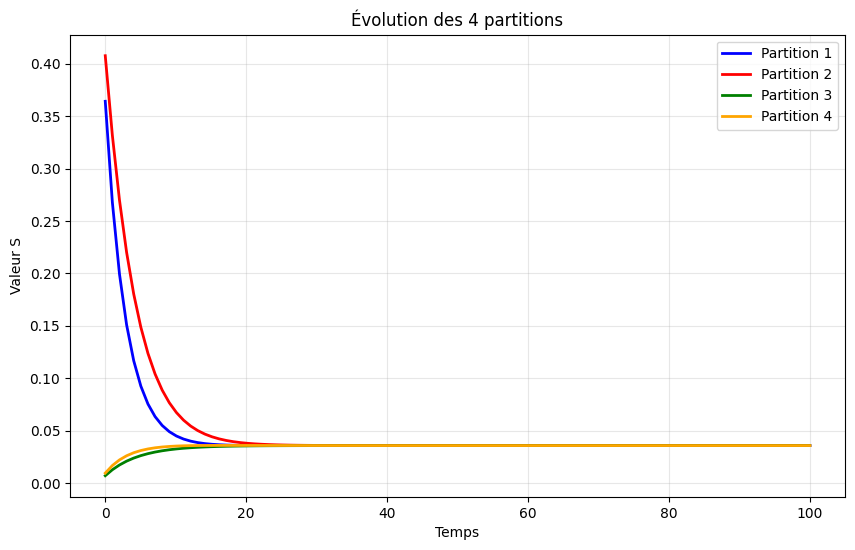

In [30]:
plt.figure(figsize=(10, 6))

# 4 partitions : colonne 0, 1, 2, 3
plt.plot(temps, S_s[:, 0], 'b-', label='Partition 1', linewidth=2)
plt.plot(temps, S_s[:, 1], 'r-', label='Partition 2', linewidth=2) 
plt.plot(temps, S_s[:, 2], 'g-', label='Partition 3', linewidth=2)
plt.plot(temps, S_s[:, 3], 'orange', label='Partition 4', linewidth=2)

plt.xlabel('Temps')
plt.ylabel('Valeur S')
plt.title('Évolution des 4 partitions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Effectuons une autre expérience cette fois ci avec un découpage en 10 parties

In [31]:
from IPython.display import HTML

def show_cylindrical_partition(nr=4, ntheta=6, radial_mode="equal_area", size=520):
    import uuid
    cid = f"cyl_{uuid.uuid4().hex}"

    html = f"""
    <div style="font-family: sans-serif;">
      <h3>Vue de dessus — nr={nr}, ntheta={ntheta}, nz=1, mode={radial_mode}</h3>
      <canvas id="{cid}" width="{size}" height="{size}" style="border:1px solid #ccc; border-radius:8px;"></canvas>
    </div>
    <script>
    (function() {{
        const canvas = document.getElementById("{cid}");
        const ctx = canvas.getContext("2d");
        const W = canvas.width, H = canvas.height;
        const cx = W/2, cy = H/2, R = W*0.42;
        const nr = {nr};
        const ntheta = {ntheta};
        const radialMode = "{radial_mode}";

        function getEdges(nr, R, mode) {{
            if (mode === "equal_area") {{
                return Array.from({{length: nr+1}}, (_, i) => R * Math.sqrt(i/nr));
            }}
            return Array.from({{length: nr+1}}, (_, i) => R * i/nr);
        }}

        const edges = getEdges(nr, R, radialMode);
        ctx.clearRect(0, 0, W, H);

        for (let itheta = 0; itheta < ntheta; itheta++) {{
            for (let ir = 0; ir < nr; ir++) {{
                const state = ir + itheta * nr;
                const t0 = itheta * 2*Math.PI / ntheta - Math.PI/2;
                const t1 = (itheta + 1) * 2*Math.PI / ntheta - Math.PI/2;
                const r0 = edges[ir];
                const r1 = edges[ir+1];

                ctx.beginPath();
                ctx.arc(cx, cy, r1, t0, t1);
                ctx.arc(cx, cy, r0, t1, t0, true);
                ctx.closePath();
                ctx.fillStyle = `hsl(${{(state*300)/(nr*ntheta)}}, 65%, 68%)`;
                ctx.fill();
                ctx.strokeStyle = "#222";
                ctx.lineWidth = 1;
                ctx.stroke();

                const rm = (r0 + r1)/2;
                const tm = (t0 + t1)/2;
                const x = cx + rm * Math.cos(tm);
                const y = cy + rm * Math.sin(tm);

                ctx.fillStyle = "#111";
                ctx.font = "12px sans-serif";
                ctx.textAlign = "center";
                ctx.textBaseline = "middle";
                ctx.fillText(String(state), x, y);
            }}
        }}

        ctx.beginPath();
        ctx.arc(cx, cy, R, 0, 2*Math.PI);
        ctx.strokeStyle = "#000";
        ctx.lineWidth = 1.5;
        ctx.stroke();
    }})();
    </script>
    """
    return HTML(html)

In [33]:
show_cylindrical_partition(nr=2,ntheta=2)

Nous 